<a href="https://colab.research.google.com/github/Akshatha7710/smart-tea-estate-management-system/blob/soil_quality-analysis_and_predictive_modeling/Soil_Quality_Analysis_and_Predictive_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.



Rainfall Forecast (Next 12 Months)
            ds        yhat  yhat_lower   yhat_upper
115 2025-11-01  464.619681  173.472041   747.502329
116 2025-12-01  234.164144  -62.636398   498.123896
117 2026-01-01   82.952444 -210.080372   350.638684
118 2026-02-01   77.679588 -201.381846   345.383515
119 2026-03-01  187.575135 -100.875761   478.064105
120 2026-04-01  304.663811   17.824372   567.549134
121 2026-05-01  852.062793  549.856870  1104.880531
122 2026-06-01  597.038261  303.167086   860.913911
123 2026-07-01  610.388716  330.704921   904.343692
124 2026-08-01  804.289734  516.749277  1090.224593
125 2026-09-01  494.151190  204.547863   771.135288
126 2026-10-01  629.322818  325.775096   912.227986

Wet Days Prediction Performance (XGBoost)
MAE: 3.3036296076100804
R2: 0.5473740254116501

Soil pH Prediction Performance (Random Forest)
MAE: 0.5063846991897003
R2: 0.2396499384010159

Cross Validation R2: [ 0.3092372   0.07056877  0.26096036 -1.32137833 -0.01953397]
Average R2: -0.1400

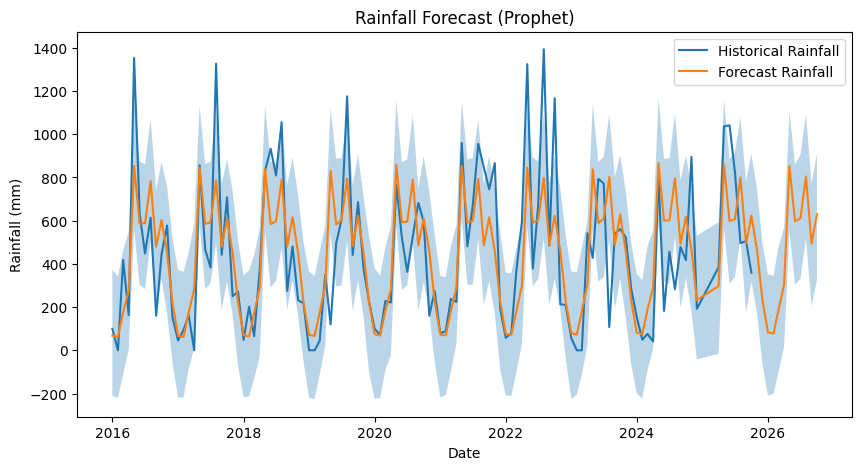

In [10]:
# ==========================================================
# STEMS - Smart Tea Estate Management System
# Improved Models
# Rainfall -> Prophet
# Wet Days -> XGBoost
# Soil pH -> Random Forest (better for small datasets)
# ==========================================================

# ==========================================================
# 1. Import Libraries
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

from prophet import Prophet

# ==========================================================
# 2. Load Datasets
# ==========================================================
rainfall = pd.read_csv("sample_data/rainfall_data.csv")
soil = pd.read_csv("sample_data/soil_data.csv")

# ==========================================================
# 3. Rainfall Data Preprocessing
# ==========================================================
rainfall["Year"] = rainfall["Year"].str.split("/").str[0].astype(int)

month_map = {
    "January":1,"February":2,"March":3,"April":4,
    "May":5,"June":6,"July":7,"August":8,
    "September":9,"October":10,"November":11,"December":12
}

rainfall["Month"] = rainfall["Month"].map(month_map)

rainfall["Date"] = pd.to_datetime(dict(
    year=rainfall.Year,
    month=rainfall.Month,
    day=1
))

rainfall = rainfall.sort_values("Date").dropna()

# ==========================================================
# 4. Rainfall Forecasting (Prophet)
# ==========================================================
rain_df = rainfall[["Date","Rainfall"]].rename(
    columns={"Date":"ds","Rainfall":"y"}
)

prophet_model = Prophet(
    yearly_seasonality=True,
    daily_seasonality=False
)

prophet_model.fit(rain_df)

future = prophet_model.make_future_dataframe(
    periods=12,
    freq="MS"
)

forecast = prophet_model.predict(future)

print("\nRainfall Forecast (Next 12 Months)")
print(forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(12))

# ==========================================================
# 5. Wet Days Prediction (XGBoost)
# ==========================================================
rainfall["Rainfall_lag1"] = rainfall["Rainfall"].shift(1)
rainfall["Rainfall_lag2"] = rainfall["Rainfall"].shift(2)
rainfall["Rainfall_3month_avg"] = rainfall["Rainfall"].rolling(3).mean()

rainfall = rainfall.dropna()

features = [
    "Rainfall",
    "Rainfall_lag1",
    "Rainfall_lag2",
    "Rainfall_3month_avg"
]

X = rainfall[features]
y = rainfall["Wet_days"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train,y_train)

wet_pred = xgb_model.predict(X_test)

print("\nWet Days Prediction Performance (XGBoost)")
print("MAE:",mean_absolute_error(y_test,wet_pred))
print("R2:",r2_score(y_test,wet_pred))

# ==========================================================
# 6. Soil Data Cleaning
# ==========================================================
soil.replace("missing",np.nan,inplace=True)

soil["pH"] = pd.to_numeric(soil["pH"],errors="coerce")
soil["C%"] = pd.to_numeric(soil["C%"],errors="coerce")
soil["Year of Planting"] = pd.to_numeric(
    soil["Year of Planting"],
    errors="coerce"
)

soil = soil.dropna()

# Feature Engineering
soil["FieldAge"] = 2025 - soil["Year of Planting"]

# ==========================================================
# 7. Soil pH Prediction (Random Forest - Better Model)
# ==========================================================

features = [
    "Extent (Ha)",
    "Category",
    "VP/SD",
    "Estate",
    "FieldAge",
    "C%"
]

X = soil[features]
y = soil["pH"]

categorical_cols = ["Category","VP/SD","Estate"]
numeric_cols = ["Extent (Ha)","FieldAge","C%"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_cols),
        ("num","passthrough",numeric_cols)
    ]
)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

pipeline = Pipeline([
    ("preprocess",preprocessor),
    ("model",rf_model)
])

# Train test split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

pipeline.fit(X_train,y_train)

soil_pred = pipeline.predict(X_test)

print("\nSoil pH Prediction Performance (Random Forest)")
print("MAE:",mean_absolute_error(y_test,soil_pred))
print("R2:",r2_score(y_test,soil_pred))

# Cross validation for stability
scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\nCross Validation R2:",scores)
print("Average R2:",scores.mean())

# ==========================================================
# 8. Rainfall Visualization
# ==========================================================
plt.figure(figsize=(10,5))

plt.plot(
    rain_df['ds'],
    rain_df['y'],
    label="Historical Rainfall"
)

plt.plot(
    forecast['ds'],
    forecast['yhat'],
    label="Forecast Rainfall"
)

plt.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    alpha=0.3
)

plt.title("Rainfall Forecast (Prophet)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()

plt.show()